Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


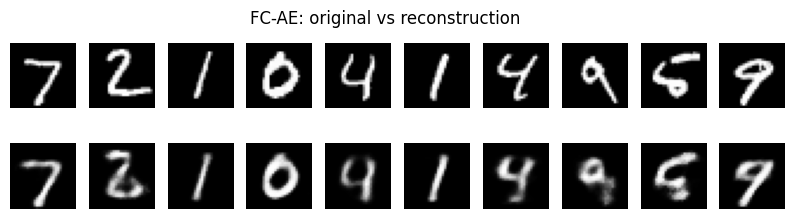

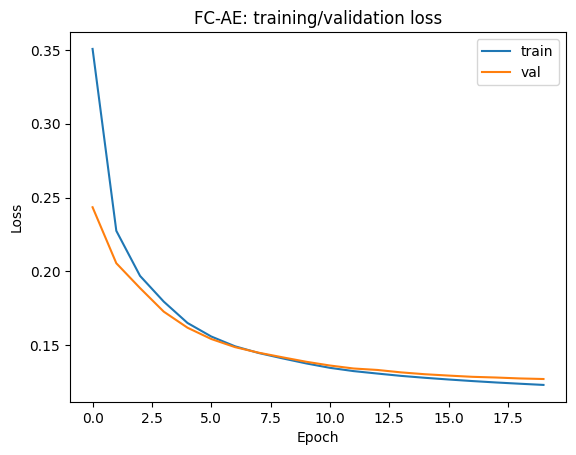

FC-AE: (np.float32(0.02207489), np.float32(0.057958316), np.float64(0.7389864534899538), 211040)


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


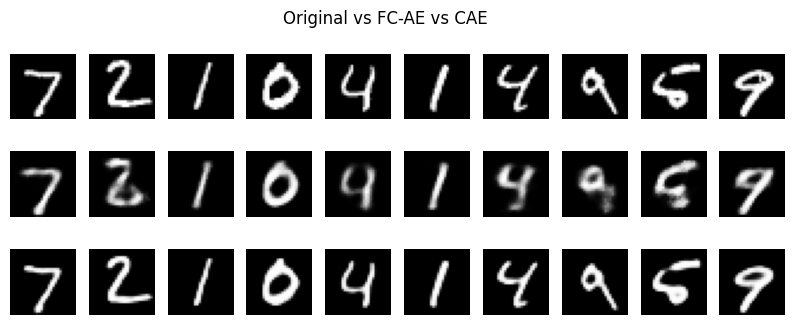

CAE: (np.float32(0.0027303074), np.float32(0.0154244695), np.float64(0.9733278108841685), 74497)


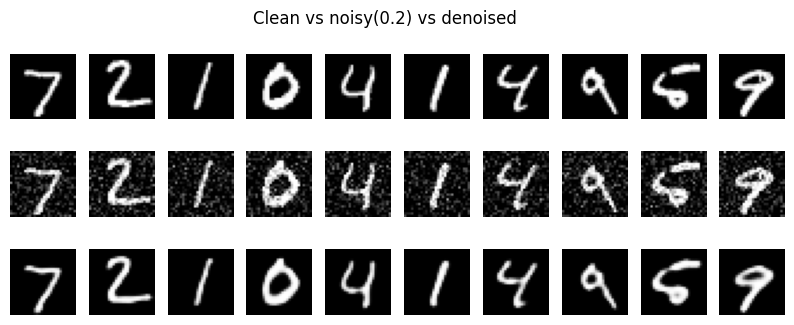

Denoising by noise level (MSE, MAE, SSIM): {0.1: (np.float32(0.003266241), np.float32(0.017218357), np.float64(0.9639013459334003)), 0.2: (np.float32(0.0044870996), np.float32(0.021033557), np.float64(0.9461795668729595)), 0.3: (np.float32(0.006666516), np.float32(0.026508313), np.float64(0.9175836972720913))}


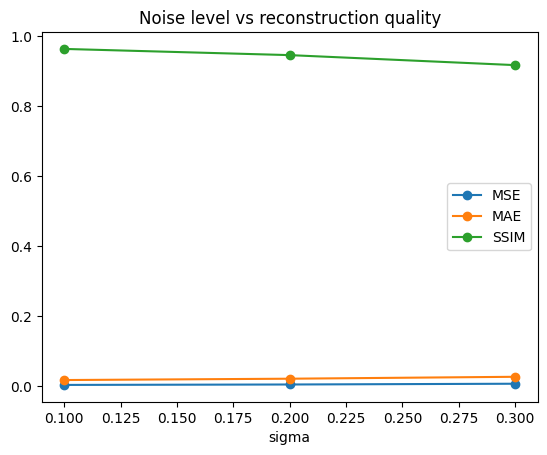

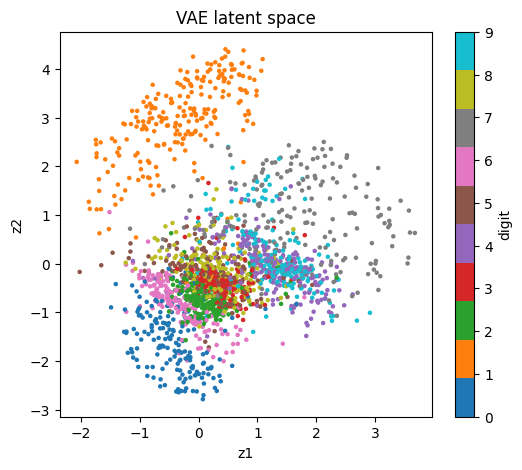

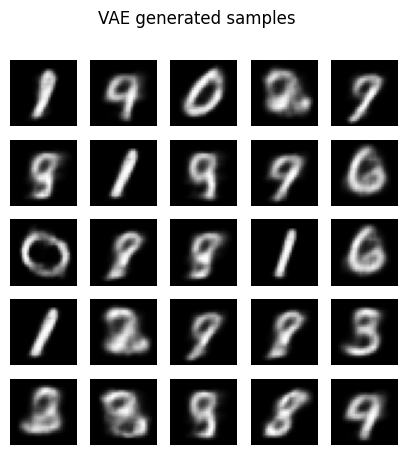

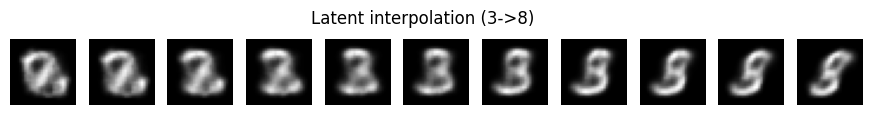

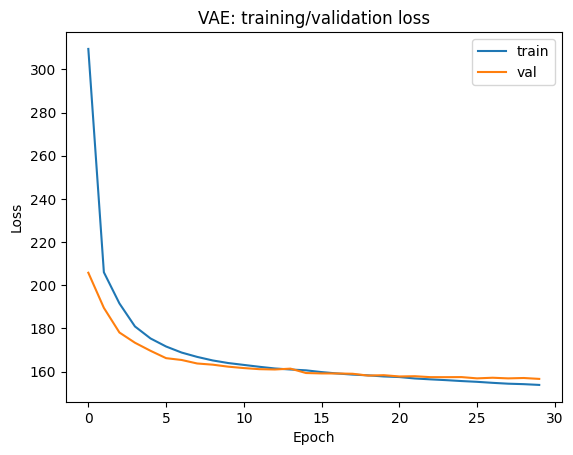

DCAE: (np.float32(0.0044870996), np.float32(0.021033557), np.float64(0.9461795668729595), 74497)
VAE: (150.7718048095703, 5.6809916496276855, 156.45281982421875, np.float32(0.04400365), np.float32(0.10228169), np.float64(0.4848093243091995), 284933)


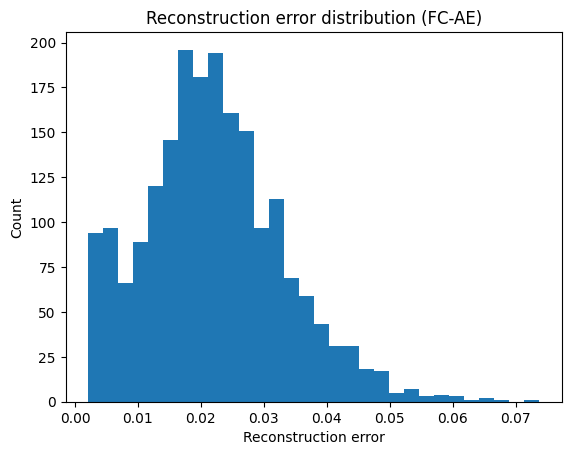

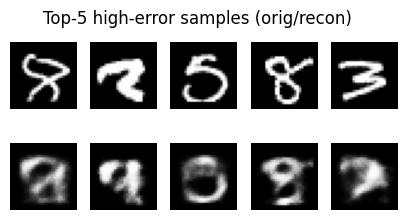

High-error labels/errors: [8 2 5 8 3] [0.07370254 0.06821429 0.06576545 0.06522068 0.0629703 ]
Consolidated results (MSE, MAE, SSIM, Params, Time): {'FC-AE': (np.float32(0.02207489), np.float32(0.057958316), np.float64(0.7389864534899538), 211040, 12.949658632278442), 'CAE': (np.float32(0.0027303074), np.float32(0.0154244695), np.float64(0.9733278108841685), 74497, 23.52978539466858), 'DCAE': (np.float32(0.0044870996), np.float32(0.021033557), np.float64(0.9461795668729595), 74497, 19.704415798187256), 'VAE': (np.float32(0.04400365), np.float32(0.10228169), np.float64(0.4848093243091995), 284933, 30.39915657043457)}
FC-AE latent-dim sweep (dz, MSE, MAE, SSIM, Params): [(2, np.float32(0.046137724), np.float32(0.107925415), np.float64(0.4507420173330586), 210130), (8, np.float32(0.026446722), np.float32(0.067655884), np.float64(0.6849364341982185), 210520), (16, np.float32(0.02207489), np.float32(0.057958316), np.float64(0.7389864534899538), 211040), (32, np.float32(0.020437416), np.floa

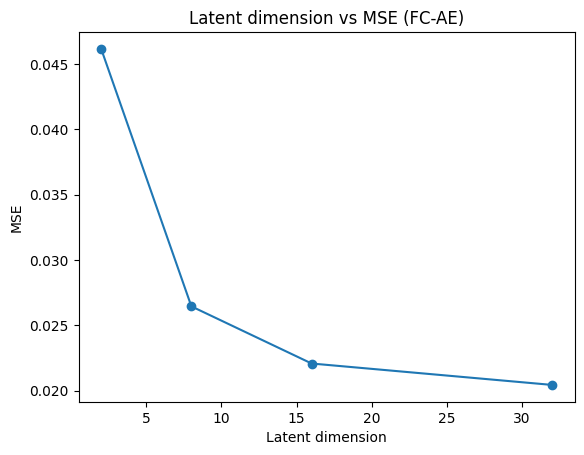

CAE latent-dim sweep (dz, MSE, MAE, SSIM, Params): [(4, np.float32(0.0044337464), np.float32(0.020058764), np.float64(0.9566321843265814), 22597), (8, np.float32(0.004384892), np.float32(0.020089587), np.float64(0.9559766005049364), 26057), (16, np.float32(0.0031175695), np.float32(0.0166804), np.float64(0.9685460298718992), 32977), (32, np.float32(0.0030348222), np.float32(0.016503233), np.float64(0.9682551493802828), 46817)]
Salt&pepper(0.1) vs Gaussian(0.1): (np.float32(0.004954262), np.float32(0.02133658), np.float64(0.9438795795529263)) (np.float32(0.003266241), np.float32(0.017218357), np.float64(0.9639013459334003))
Transpose-decoder CAE vs UpSampling CAE: (np.float32(0.002317994), np.float32(0.014220593), np.float64(0.9760194441581449)) (np.float32(0.0027303074), np.float32(0.0154244695), np.float64(0.9733278108841685))
VAE dz=2 vs dz=8: (np.float32(0.04400365), np.float32(0.10228169), np.float64(0.4848093243091995)) (np.float32(0.018963104), np.float32(0.05149207), np.float64(

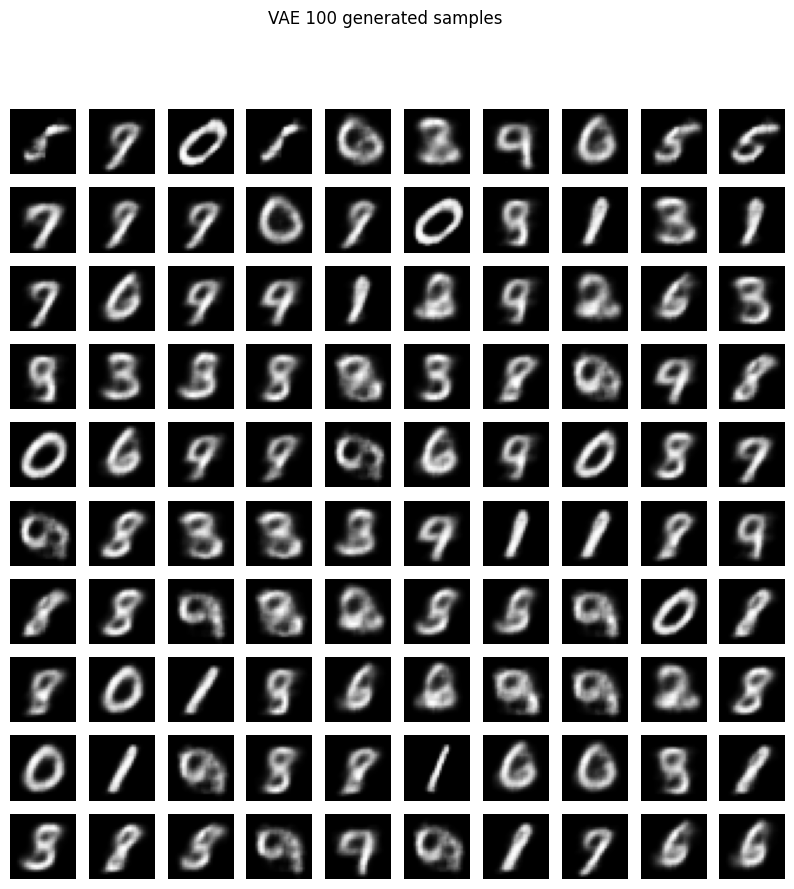

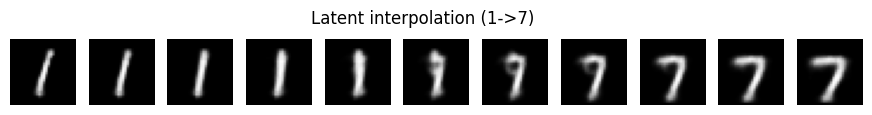

Done. Saved under /content/drive/MyDrive/CS3807_Exp7


In [2]:
import os, time, pickle, datetime
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

np.random.seed(0); tf.random.set_seed(0)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/CS3807_Exp7'
except Exception:
    ROOT = './CS3807_Exp7'
MODELS, RESULTS = f'{ROOT}/models', f'{ROOT}/results'
os.makedirs(MODELS, exist_ok=True); os.makedirs(RESULTS, exist_ok=True)
TS = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

def run_or_load(name, build_fn, train_fn):
    model = build_fn()
    wpath, mpath = f'{MODELS}/{name}.weights.h5', f'{MODELS}/{name}_meta.pkl'
    if os.path.exists(wpath) and os.path.exists(mpath):
        model.load_weights(wpath)
        meta = pickle.load(open(mpath, 'rb'))
        return model, meta['history'], meta['time']
    t0 = time.time()
    hist = train_fn(model)
    elapsed = time.time() - t0
    model.save_weights(wpath)
    model.save_weights(f'{MODELS}/{name}_{TS}.weights.h5')
    h = hist.history if hasattr(hist, 'history') else hist
    pickle.dump({'history': h, 'time': elapsed}, open(mpath, 'wb'))
    return model, h, elapsed

# dataset
(xtr, ytr), (xte, yte) = keras.datasets.mnist.load_data()
xtr, ytr, xte, yte = xtr[:10000], ytr[:10000], xte[:2000], yte[:2000]
xtr, xte = xtr.astype('float32') / 255., xte.astype('float32') / 255.
xtr_flat, xte_flat = xtr.reshape(-1, 784), xte.reshape(-1, 784)
xtr_c, xte_c = xtr[..., None], xte[..., None]

def metrics(x, xhat):
    x, xhat = x.reshape(-1, 28, 28), xhat.reshape(-1, 28, 28)
    mse, mae = np.mean((x - xhat) ** 2), np.mean(np.abs(x - xhat))
    s = np.mean([ssim(x[i], xhat[i], data_range=1.0) for i in range(len(x))])
    return mse, mae, s

def grid(rows, title, name, n=10):
    fig, ax = plt.subplots(len(rows), n, figsize=(n, 1.2 * len(rows)))
    for r in range(len(rows)):
        for i in range(n):
            ax[r, i].imshow(rows[r][i].reshape(28, 28), cmap='gray'); ax[r, i].axis('off')
    fig.suptitle(title); fig.savefig(f'{RESULTS}/{name}.png'); plt.show()

def plot_loss(hist, title, name):
    plt.figure(); plt.plot(hist['loss'], label='train'); plt.plot(hist['val_loss'], label='val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title(title)
    plt.savefig(f'{RESULTS}/{name}.png'); plt.show()

def sweep(tag_prefix, build_fn, train_fn, dzs, predict_fn):
    out = []
    for dz in dzs:
        m, _, _ = run_or_load(f'{tag_prefix}{dz}', lambda dz=dz: build_fn(dz), train_fn)
        out.append((dz,) + metrics(xte_c, predict_fn(m)) + (m.count_params(),))
    return out

# fully connected autoencoder
def build_fc_ae(latent=16):
    inp = layers.Input((784,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dense(32, activation='relu')(x)
    z = layers.Dense(latent, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(z)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(784, activation='sigmoid')(x)
    m = keras.Model(inp, out); m.compile('adam', 'binary_crossentropy')
    return m

def train_fc(m):
    return m.fit(xtr_flat, xtr_flat, validation_data=(xte_flat, xte_flat), epochs=20, batch_size=128, verbose=0)

fc_ae, fc_hist, t_fc = run_or_load('fc_ae16', lambda: build_fc_ae(16), train_fc)
xhat_fc = fc_ae.predict(xte_flat, verbose=0)
mse_fc, mae_fc, ssim_fc = metrics(xte_c, xhat_fc)

grid([xte_flat, xhat_fc], 'FC-AE: original vs reconstruction', 'orig_recon_fc')
plot_loss(fc_hist, 'FC-AE: training/validation loss', 'loss_fc')
print('FC-AE:', (mse_fc, mae_fc, ssim_fc, fc_ae.count_params()))

# convolutional autoencoder
def build_cae(latent=64, use_transpose=False):
    inp = layers.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(latent, 3, activation='relu', padding='same')(x)
    if use_transpose:
        x = layers.Conv2DTranspose(32, 3, strides=(2, 2), activation='relu', padding='same')(x)
        x = layers.Conv2DTranspose(32, 3, strides=(2, 2), activation='relu', padding='same')(x)
    else:
        x = layers.UpSampling2D((2, 2))(x)
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
        x = layers.UpSampling2D((2, 2))(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    m = keras.Model(inp, out); m.compile('adam', 'binary_crossentropy')
    return m

def train_cae(m):
    return m.fit(xtr_c, xtr_c, validation_data=(xte_c, xte_c), epochs=20, batch_size=128, verbose=0)

cae, _, t_cae = run_or_load('cae64', lambda: build_cae(64), train_cae)
xhat_cae = cae.predict(xte_c, verbose=0)
mse_cae, mae_cae, ssim_cae = metrics(xte_c, xhat_cae)

grid([xte, xhat_fc, xhat_cae], 'Original vs FC-AE vs CAE', 'fc_vs_cae')
print('CAE:', (mse_cae, mae_cae, ssim_cae, cae.count_params()))

# denoising CAE across noise levels
def add_noise(x, kind='gaussian', level=0.2):
    if kind == 'gaussian':
        return np.clip(x + np.random.normal(0, level, x.shape), 0, 1)
    xn = x.copy(); mask = np.random.rand(*x.shape)
    xn[mask < level / 2] = 0.; xn[mask > 1 - level / 2] = 1.
    return xn

def make_dcae_trainer(sigma):
    def train(m):
        xn, xnv = add_noise(xtr_c, 'gaussian', sigma), add_noise(xte_c, 'gaussian', sigma)
        return m.fit(xn, xtr_c, validation_data=(xnv, xte_c), epochs=20, batch_size=128, verbose=0)
    return train

noise_results = {}
for sigma in [0.1, 0.2, 0.3]:
    tag = f'dcae_g{str(sigma).replace(".", "p")}'
    m, _, t = run_or_load(tag, lambda: build_cae(64), make_dcae_trainer(sigma))
    xh = m.predict(add_noise(xte_c, 'gaussian', sigma), verbose=0)
    noise_results[sigma] = metrics(xte_c, xh)
    if sigma == 0.2:
        dcae, t_dcae = m, t

mse_dn, mae_dn, ssim_dn = noise_results[0.2]
xte_noisy02 = add_noise(xte_c, 'gaussian', 0.2)
xhat_dn = dcae.predict(xte_noisy02, verbose=0)
grid([xte, xte_noisy02, xhat_dn], 'Clean vs noisy(0.2) vs denoised', 'denoising')
print('Denoising by noise level (MSE, MAE, SSIM):', noise_results)

plt.figure()
for i, lbl in enumerate(['MSE', 'MAE', 'SSIM']):
    plt.plot([0.1, 0.2, 0.3], [noise_results[s][i] for s in [0.1, 0.2, 0.3]], marker='o', label=lbl)
plt.xlabel('sigma'); plt.legend(); plt.title('Noise level vs reconstruction quality')
plt.savefig(f'{RESULTS}/noise_vs_quality.png'); plt.show()

# variational autoencoder
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        return mu + tf.exp(0.5 * logvar) * tf.random.normal(tf.shape(mu))

class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=1.0):
        super().__init__()
        self.encoder, self.decoder, self.kl_weight = encoder, decoder, kl_weight
        self.loss_tracker = keras.metrics.Mean(name='loss')
        self.rec_tracker = keras.metrics.Mean(name='rec_loss')
        self.kl_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.loss_tracker, self.rec_tracker, self.kl_tracker]

    def call(self, x):
        mu, logvar, z = self.encoder(x); return self.decoder(z)

    def _step(self, x):
        mu, logvar, z = self.encoder(x)
        xhat = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, xhat), axis=(1, 2)))
        kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
        return rec, kl

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            rec, kl = self._step(x); loss = rec + self.kl_weight * kl
        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        rec, kl = self._step(x); loss = rec + self.kl_weight * kl
        self.loss_tracker.update_state(loss); self.rec_tracker.update_state(rec); self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

def build_vae(latent_dim=2, kl_weight=1.0):
    enc_in = layers.Input((28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=(2, 2), padding='same')(enc_in)
    x = layers.Conv2D(64, 3, activation='relu', strides=(2, 2), padding='same')(x)
    shape_before = x.shape[1:]
    x = layers.Flatten()(x); x = layers.Dense(64, activation='relu')(x)
    mu, logvar = layers.Dense(latent_dim)(x), layers.Dense(latent_dim)(x)
    z = Sampling()([mu, logvar])
    encoder = keras.Model(enc_in, [mu, logvar, z], name='encoder')

    dec_in = layers.Input((latent_dim,))
    x = layers.Dense(int(np.prod(shape_before)), activation='relu')(dec_in)
    x = layers.Reshape(shape_before)(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=(2, 2), padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=(2, 2), padding='same')(x)
    dec_out = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
    decoder = keras.Model(dec_in, dec_out, name='decoder')

    vae = VAE(encoder, decoder, kl_weight); vae.compile(optimizer='adam')
    vae(tf.zeros((1, 28, 28, 1)))
    return vae

def train_vae(m):
    return m.fit(xtr_c, xtr_c, validation_data=(xte_c, xte_c), epochs=30, batch_size=128, verbose=0)

def generate_grid(decoder, n, latent_dim, title, name):
    imgs = decoder.predict(np.random.normal(size=(n, latent_dim)), verbose=0)
    side = int(np.ceil(np.sqrt(n)))
    fig, ax = plt.subplots(side, side, figsize=(side, side))
    for i in range(side * side):
        ax.flat[i].axis('off')
        if i < n: ax.flat[i].imshow(imgs[i].reshape(28, 28), cmap='gray')
    fig.suptitle(title); fig.savefig(f'{RESULTS}/{name}.png'); plt.show()

def interpolate(decoder, zA, zB, title, name, steps=11):
    zs = np.array([(1 - a) * zA + a * zB for a in np.linspace(0, 1, steps)])
    imgs = decoder.predict(zs, verbose=0)
    fig, ax = plt.subplots(1, steps, figsize=(steps, 1.3))
    for i in range(steps):
        ax[i].imshow(imgs[i].reshape(28, 28), cmap='gray'); ax[i].axis('off')
    fig.suptitle(title); fig.savefig(f'{RESULTS}/{name}.png'); plt.show()

vae2, vae2_hist, t_vae = run_or_load('vae_z2', lambda: build_vae(2), train_vae)
mu_te, logvar_te, z_te = vae2.encoder.predict(xte_c, verbose=0)
xhat_vae = vae2.decoder.predict(mu_te, verbose=0)
mse_vae, mae_vae, ssim_vae = metrics(xte_c, xhat_vae)
loss_v, rec_v, kl_v = vae2.evaluate(xte_c, verbose=0)

plt.figure(figsize=(6, 5))
sc = plt.scatter(mu_te[:, 0], mu_te[:, 1], c=yte, cmap='tab10', s=5)
plt.colorbar(sc, label='digit'); plt.xlabel('z1'); plt.ylabel('z2'); plt.title('VAE latent space')
plt.savefig(f'{RESULTS}/vae_latent_space.png'); plt.show()

generate_grid(vae2.decoder, 25, 2, 'VAE generated samples', 'vae_generated')
idxA, idxB = np.where(yte == 3)[0][0], np.where(yte == 8)[0][0]
interpolate(vae2.decoder, mu_te[idxA], mu_te[idxB], 'Latent interpolation (3->8)', 'interp_3_8')
plot_loss(vae2_hist, 'VAE: training/validation loss', 'loss_vae')

print('DCAE:', (mse_dn, mae_dn, ssim_dn, dcae.count_params()))
print('VAE:', (rec_v, kl_v, loss_v, mse_vae, mae_vae, ssim_vae, vae2.count_params()))

# reconstruction-error distribution + high-error samples (FC-AE)
errors = np.mean((xte_flat - xhat_fc) ** 2, axis=1)
plt.figure(); plt.hist(errors, bins=30); plt.xlabel('Reconstruction error'); plt.ylabel('Count')
plt.title('Reconstruction error distribution (FC-AE)')
plt.savefig(f'{RESULTS}/error_distribution.png'); plt.show()

top5 = np.argsort(errors)[-5:][::-1]
grid([xte[top5], xhat_fc[top5]], 'Top-5 high-error samples (orig/recon)', 'high_error_samples', n=5)
print('High-error labels/errors:', yte[top5], errors[top5])

print('Consolidated results (MSE, MAE, SSIM, Params, Time):', {
    'FC-AE': (mse_fc, mae_fc, ssim_fc, fc_ae.count_params(), t_fc),
    'CAE': (mse_cae, mae_cae, ssim_cae, cae.count_params(), t_cae),
    'DCAE': (mse_dn, mae_dn, ssim_dn, dcae.count_params(), t_dcae),
    'VAE': (mse_vae, mae_vae, ssim_vae, vae2.count_params(), t_vae),
})

# latent-dimension sweeps
fc_sweep = sweep('fc_ae', build_fc_ae, train_fc, [2, 8, 16, 32], lambda m: m.predict(xte_flat, verbose=0))
print('FC-AE latent-dim sweep (dz, MSE, MAE, SSIM, Params):', fc_sweep)
plt.figure(); plt.plot([r[0] for r in fc_sweep], [r[1] for r in fc_sweep], marker='o')
plt.xlabel('Latent dimension'); plt.ylabel('MSE'); plt.title('Latent dimension vs MSE (FC-AE)')
plt.savefig(f'{RESULTS}/latentdim_vs_mse.png'); plt.show()

cae_sweep = sweep('cae', build_cae, train_cae, [4, 8, 16, 32], lambda m: m.predict(xte_c, verbose=0))
print('CAE latent-dim sweep (dz, MSE, MAE, SSIM, Params):', cae_sweep)

# additional exercises
def train_dcae_sp(m):
    xn, xnv = add_noise(xtr_c, 'sp', 0.1), add_noise(xte_c, 'sp', 0.1)
    return m.fit(xn, xtr_c, validation_data=(xnv, xte_c), epochs=20, batch_size=128, verbose=0)

dcae_sp, _, _ = run_or_load('dcae_sp01', lambda: build_cae(64), train_dcae_sp)
xh_sp = dcae_sp.predict(add_noise(xte_c, 'sp', 0.1), verbose=0)
print('Salt&pepper(0.1) vs Gaussian(0.1):', metrics(xte_c, xh_sp), noise_results[0.1])

cae_t, _, _ = run_or_load('cae_transpose', lambda: build_cae(64, use_transpose=True), train_cae)
xh_t = cae_t.predict(xte_c, verbose=0)
print('Transpose-decoder CAE vs UpSampling CAE:', metrics(xte_c, xh_t), (mse_cae, mae_cae, ssim_cae))

vae8, _, _ = run_or_load('vae_z8', lambda: build_vae(8), train_vae)
mu8, _, _ = vae8.encoder.predict(xte_c, verbose=0)
print('VAE dz=2 vs dz=8:', (mse_vae, mae_vae, ssim_vae), metrics(xte_c, vae8.decoder.predict(mu8, verbose=0)))

vae_klhigh, _, _ = run_or_load('vae_z2_klw5', lambda: build_vae(2, kl_weight=5.0), train_vae)
loss_k, rec_k, kl_k = vae_klhigh.evaluate(xte_c, verbose=0)
print(f'KL weight 1 vs 5: rec={rec_v:.4f}/{rec_k:.4f} kl={kl_v:.4f}/{kl_k:.4f}')

generate_grid(vae2.decoder, 100, 2, 'VAE 100 generated samples', 'vae_100_samples')
idxC, idxD = np.where(yte == 1)[0][0], np.where(yte == 7)[0][0]
interpolate(vae2.decoder, mu_te[idxC], mu_te[idxD], 'Latent interpolation (1->7)', 'interp_1_7')

pickle.dump({
    'fc_ae': (mse_fc, mae_fc, ssim_fc, fc_ae.count_params(), t_fc),
    'cae': (mse_cae, mae_cae, ssim_cae, cae.count_params(), t_cae),
    'dcae_sigma0.2': (mse_dn, mae_dn, ssim_dn, dcae.count_params(), t_dcae),
    'vae_z2': (mse_vae, mae_vae, ssim_vae, vae2.count_params(), t_vae, rec_v, kl_v, loss_v),
    'noise_results': noise_results,
    'fc_latent_sweep': fc_sweep,
    'cae_latent_sweep': cae_sweep,
}, open(f'{RESULTS}/summary_{TS}.pkl', 'wb'))
print('Done. Saved under', ROOT)